# Olist Freight Pricing — EDA & BI

**Notebook:** `01_eda_and_bi.ipynb` | **Episode 1** | Reference: Morettin Ch. 1

---

## 1. Setup

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
conn = sqlite3.connect('/Volumes/STORAGE/olist-freight-pricing-engine/data/raw/olist.sqlite')

## 2. Database Structure

In [3]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
tables

,name
0,product_category_name_translation
1,sellers
2,customers
3,geolocation
4,order_items
5,order_payments
6,order_reviews
7,orders
8,products
9,leads_qualified


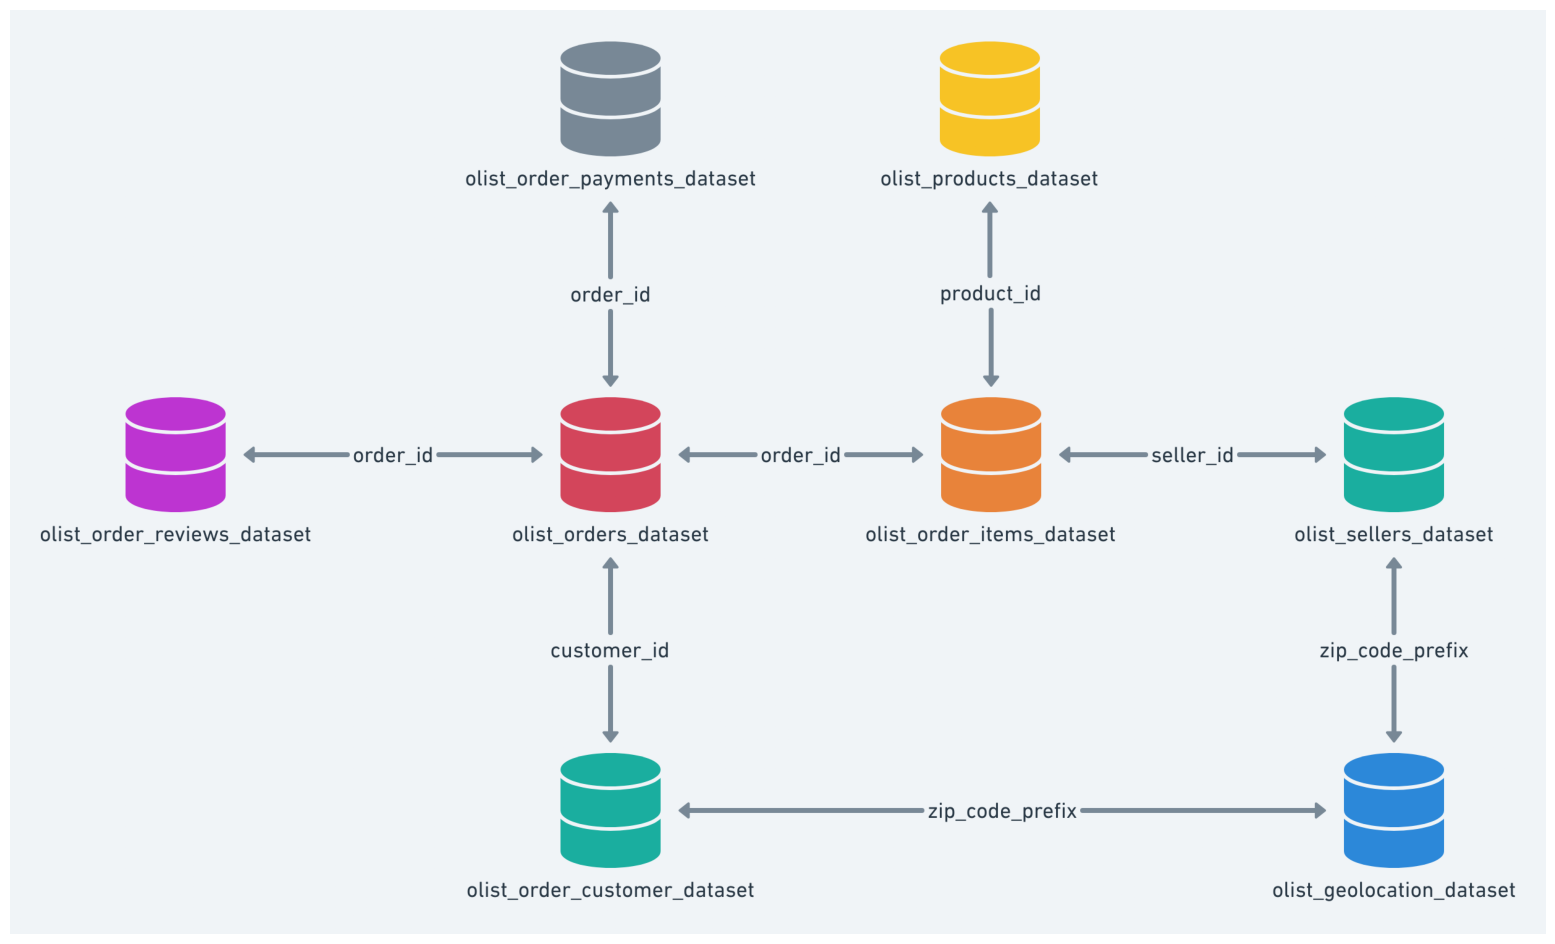

In [4]:
plt.figure(figsize=(20, 12))
img = mpimg.imread('/Volumes/STORAGE/olist-freight-pricing-engine/img/sql_structure_olist.png')
plt.imshow(img)
plt.axis('off')
plt.show()

## 3. Loading and Merge

Granularity: **order_item**. Central table: `orders`.

Pre-merge treatments:
- `order_payments`: aggregated by `order_id` (sum of value, max installments, most frequent payment type)
- `order_reviews`: only the most recent review per order is kept
- `geolocation`: deduplicated by `zip_code_prefix` and joined twice (seller and customer)

In [5]:
# load all tables
legend_table   = pd.read_sql("SELECT * FROM product_category_name_translation", conn)
df_sellers     = pd.read_sql("SELECT * FROM sellers", conn)
df_customers   = pd.read_sql("SELECT * FROM customers", conn)
df_geolocation = pd.read_sql("SELECT * FROM geolocation", conn)
df_order_items = pd.read_sql("SELECT * FROM order_items", conn)
df_orders      = pd.read_sql("SELECT * FROM orders", conn)
df_products    = pd.read_sql("SELECT * FROM products", conn)
df_payments    = pd.read_sql("SELECT * FROM order_payments", conn)
df_reviews     = pd.read_sql("SELECT * FROM order_reviews", conn)

# geolocation: one record per zip code prefix (avoids row explosion on merge)
df_geo = df_geolocation.drop_duplicates(subset='geolocation_zip_code_prefix')

# payments: aggregate per order
df_payments_agg = (
    df_payments
    .groupby('order_id', as_index=False)
    .agg(
        payment_installments=('payment_installments', 'max'),
        payment_value=('payment_value', 'sum'),
        payment_type=('payment_type', lambda x: x.mode()[0])
    )
)

# reviews: keep most recent review per order
df_reviews_last = (
    df_reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates(subset='order_id')
    [['order_id', 'review_score', 'review_creation_date']]
)

# main merge
df = (
    df_order_items
    .merge(df_orders,       on='order_id',   how='left')
    .merge(df_products,     on='product_id', how='left')
    .merge(legend_table,    on='product_category_name', how='left')
    .merge(df_sellers,      on='seller_id',  how='left')
    .merge(df_customers,    on='customer_id', how='left')
    .merge(df_payments_agg, on='order_id',   how='left')
    .merge(df_reviews_last, on='order_id',   how='left')
    .merge(
        df_geo.rename(columns={
            'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
            'geolocation_lat': 'seller_lat',
            'geolocation_lng': 'seller_lng',
            'geolocation_city': 'seller_city_geo',
            'geolocation_state': 'seller_state_geo'
        }),
        on='seller_zip_code_prefix', how='left'
    )
    .merge(
        df_geo.rename(columns={
            'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
            'geolocation_lat': 'customer_lat',
            'geolocation_lng': 'customer_lng',
            'geolocation_city': 'customer_city_geo',
            'geolocation_state': 'customer_state_geo'
        }),
        on='customer_zip_code_prefix', how='left'
    )
)

print(f"Shape: {df.shape}")
df.head()

Shape: (112650, 43)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_score,review_creation_date,seller_lat,seller_lng,seller_city_geo,seller_state_geo,customer_lat,customer_lng,customer_city_geo,customer_state_geo
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,5.0,2017-09-21 00:00:00,-22.498183,-44.123614,volta redonda,RJ,-21.758076,-41.312633,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,4.0,2017-05-13 00:00:00,-23.566258,-46.518417,sao paulo,SP,-20.212393,-50.941471,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,5.0,2018-01-23 00:00:00,-22.264094,-46.158564,borda da mata,MG,-19.860439,-44.597972,pará de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,4.0,2018-08-15 00:00:00,-20.548228,-47.395897,franca,SP,-23.144923,-46.539830,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,5.0,2017-03-02 00:00:00,-22.931427,-53.133759,loanda,PR,-23.249008,-46.824961,varzea paulista,SP


## 4. Data Quality

### Identified Issues

### Type Issues
- All date columns are stored as `object` — convert to `datetime`
- `product_name_lenght` and `product_description_lenght` have a typo from the original dataset (keep as-is for traceability)

In [13]:
null = df.isnull().sum()
null_sorted = null[null > 0].sort_values(ascending = False)
round(null_sorted/len(df)*100,2)

order_delivered_customer_date    2.18
product_category_name_english    1.44
product_category_name            1.42
product_name_lenght              1.42
product_description_lenght       1.42
product_photos_qty               1.42
order_delivered_carrier_date     1.06
review_creation_date             0.84
review_score                     0.84
customer_state_geo               0.27
customer_lat                     0.27
customer_city_geo                0.27
customer_lng                     0.27
seller_city_geo                  0.22
seller_lng                       0.22
seller_lat                       0.22
seller_state_geo                 0.22
product_height_cm                0.02
product_length_cm                0.02
product_weight_g                 0.02
product_width_cm                 0.02
order_approved_at                0.01
payment_type                     0.00
payment_value                    0.00
payment_installments             0.00
dtype: float64

In [14]:
df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,review_score,review_creation_date,seller_lat,seller_lng,seller_city_geo,seller_state_geo,customer_lat,customer_lng,customer_city_geo,customer_state_geo
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,5.0,2017-09-21 00:00:00,-22.498183,-44.123614,volta redonda,RJ,-21.758076,-41.312633,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,4.0,2017-05-13 00:00:00,-23.566258,-46.518417,sao paulo,SP,-20.212393,-50.941471,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,5.0,2018-01-23 00:00:00,-22.264094,-46.158564,borda da mata,MG,-19.860439,-44.597972,pará de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,4.0,2018-08-15 00:00:00,-20.548228,-47.395897,franca,SP,-23.144923,-46.539830,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,5.0,2017-03-02 00:00:00,-22.931427,-53.133759,loanda,PR,-23.249008,-46.824961,varzea paulista,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,5.0,2018-05-11 00:00:00,-26.912429,-48.677381,itajai,SC,-2.490420,-44.303287,sao luis,MA
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,5.0,2018-07-24 00:00:00,-23.535536,-46.643052,sao paulo,SP,-25.601485,-49.317700,curitiba,PR
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,5.0,2017-10-29 00:00:00,-25.469214,-49.293935,curitiba,PR,-23.597813,-46.650272,sao paulo,SP
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,5.0,2017-08-17 00:00:00,-23.636657,-46.694780,são paulo,SP,-23.036935,-46.982526,vinhedo,SP
